# Importing the libraries

In [2]:
#install lifetimes
!pip install lifetimes
#for Mathematical Operations
import numpy as np

#for dataframe Operations
import pandas as pd

#for data visualizations
import seaborn as sns
import matplotlib.pyplot as plt

#for  RMF Analysis
from lifetimes.plotting import plot_frequency_recency_matrix, plot_probability_alive_matrix
from lifetimes.utils import summary_data_from_transaction_data

# Preparing the Dataset

In [3]:
#lets read the data set
df=pd.read_excel(r"C:\Users\Aryan\Downloads\Online Retail.xlsx")

#print the shape of the dataset
print("Shape of the Dataset:",df.shape)

Shape of the Dataset: (541909, 8)


In [4]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [5]:
#lets check the head of the dataset
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
#preparing the Dataset for calculating the customer lifetime value

#converting the data column into a Date-time object
df['InovoiceDate']=pd.to_datetime(df['InvoiceDate']).dt.date

#removing all the records where customer ID is not given
df=df[pd.notnull(df['CustomerID'])]

#removing all the customer where is the quantity of items is 0 or Negative
df=df[(df['Quantity']>0)]

#creating a new feature sales to perform RFM Analysis
df['Sales']=df['Quantity']*df['UnitPrice']

#Considering only those columns which are important for  the  analysis
cols_of_interest=['CustomerID','InvoiceDate','Sales']
#Lets check the head of the dataset
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InovoiceDate,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010-12-01,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010-12-01,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,20.34


In [7]:
#Getting some more Insights from the Dataset
print("Number of Unique Customers:",df['CustomerID'].nunique())
print("Insights on Sales")
print('---------------------')
print("Minimum Sales:",df['Sales'].min())
print("Average Sales:",df['Sales'].mean())
print("Maximum Sales:",df['Sales'].max())
print("Insights  on  Date")
print("----------------------")
print("First Date:",df['InvoiceDate'].min())
print("Last Date:",df['InvoiceDate'].min())

Number of Unique Customers: 4339
Insights on Sales
---------------------
Minimum Sales: 0.0
Average Sales: 22.394748504739596
Maximum Sales: 168469.6
Insights  on  Date
----------------------
First Date: 2010-12-01 08:26:00
Last Date: 2010-12-01 08:26:00


# CLV Model

In [8]:
# NOW lets calculate the frequecny , recency and time using the summary-data-from-transaction function

# We hsvr yo specify as monetary value and Observation period end as the last date
data = summary_data_from_transaction_data(df,'CustomerID',
                                            'InvoiceDate',
                                            monetary_value_col="Sales",
                                            observation_period_end='2011-12-9')

#lets check the hard of the dataset
data.head()

,frequency,recency,T,monetary_value
CustomerID,,,,
12346.0,0.0,0.0,325.0,0.000000
12347.0,6.0,365.0,367.0,599.701667
12348.0,3.0,283.0,358.0,301.480000
12349.0,0.0,0.0,18.0,0.000000
12350.0,0.0,0.0,310.0,0.000000


In [9]:
# lets check the stats about the New data created

print("Insights on Frequency")
print("--------------------------------")
print("Minimumm value of Frequency :",data['frequency'].min())
print("Average value of Frequency :",data['frequency'].mean())
print("Maximum value of Frequency :",data['frequency'].max())

print("Insights on Recency")
print("--------------------------------")
print("Minimum value of Recency :",data['recency'].min())
print("Average value of Recency :",data['recency'].mean())
print("Maximum value of Recency :",data['recency'].max())

print("Insights on Recency")
print("--------------------------------")
print("Minimum value of Duration of Customer :",data['T'].min())
print("Average value of Duration of Customer :",data['T'].mean())
print("Maximum value of Duration of Customer :",data['T'].max())


Insights on Frequency
--------------------------------
Minimumm value of Frequency : 0.0
Average value of Frequency : 2.8640239686563724
Maximum value of Frequency : 131.0
Insights on Recency
--------------------------------
Minimum value of Recency : 0.0
Average value of Recency : 130.74141507259736
Maximum value of Recency : 373.0
Insights on Recency
--------------------------------
Minimum value of Duration of Customer : 0.0
Average value of Duration of Customer : 222.78289928554966
Maximum value of Duration of Customer : 373.0


In [10]:
# Lets check the percentage of customer who their frequency, Recency, T and Monetary value as 0

print("Percentage of Customer who Have Frequency value as 0 : {0:.2f}%".format(sum(data['frequency'] ==0)/float(len(data))))
print("Percentage of Customer who Have Recency value as 0 : {0:.2f}%".format(sum(data['recency'] == 0)/float(len(data))))
print("Percentage of Customer who Have Recency value as 0 : {0:.2f}%".format(sum(data['monetary_value']==0)/float(len(data))))

Percentage of Customer who Have Frequency value as 0 : 0.36%
Percentage of Customer who Have Recency value as 0 : 0.36%
Percentage of Customer who Have Recency value as 0 : 0.36%


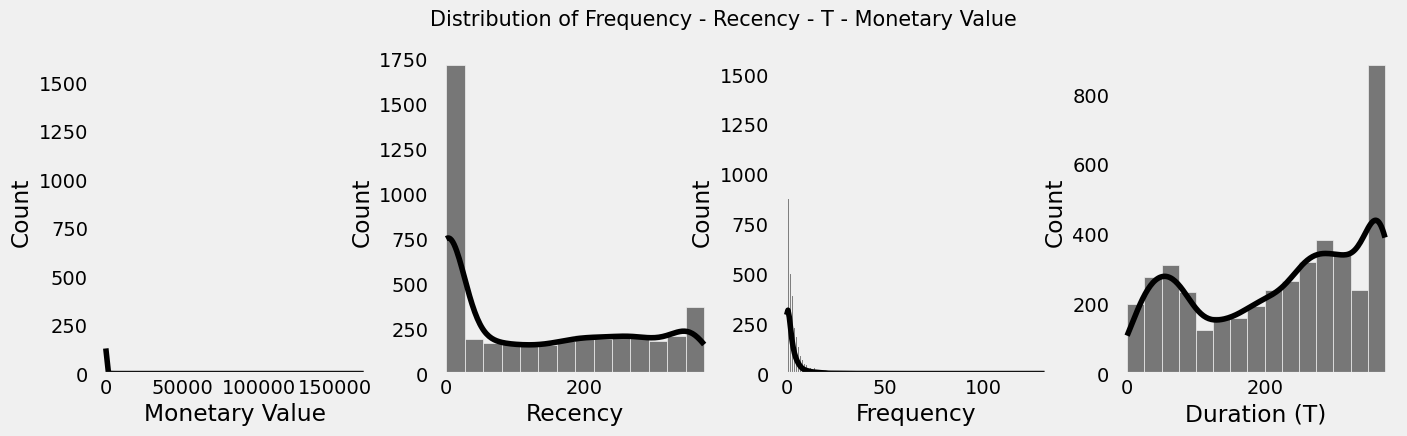

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (15,4)
plt.style.use('fivethirtyeight')

plt.subplot(1,4,1)
sns.histplot(data['monetary_value'], color='black', kde=True)
plt.xlabel('Monetary Value')
plt.grid()

plt.subplot(1,4,2)
sns.histplot(data['recency'], color='black', kde=True)
plt.xlabel('Recency')
plt.grid()

plt.subplot(1,4,3)
sns.histplot(data['frequency'], color='black', kde=True)
plt.xlabel('Frequency')
plt.grid()

plt.subplot(1,4,4)
sns.histplot(data['T'], color='black', kde=True)
plt.xlabel('Duration (T)')
plt.grid()

plt.suptitle('Distribution of Frequency - Recency - T - Monetary Value', fontsize=15)

plt.show()

# Frequecny and Recency Analysis

In [12]:
from lifetimes import BetaGeoFitter

# Making a Beta Geo Fitter Model Penalizer Coefficient as 0.1
bgf = BetaGeoFitter(penalizer_coef=0.1)

# Fedding the Model with Frequency, Recency, and Duration
bgf.fit(data['frequency'], data['recency'], data['T'])

# lets check the Model Parameters
print(bgf)

<lifetimes.BetaGeoFitter: fitted with 4339 subjects, a: 0.00, alpha: 49.41, b: 0.00, r: 0.59>


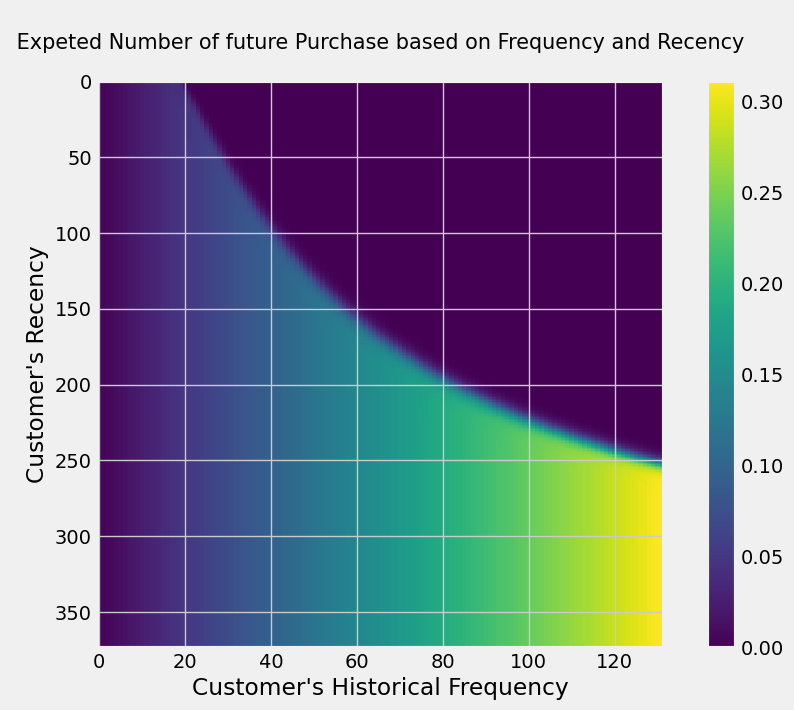

In [13]:
from lifetimes.plotting import plot_frequency_recency_matrix

plt.rcParams['figure.figsize']=(10,7)

#lets plot the recency vs frequecny matrix
plot_frequency_recency_matrix(bgf)
plt.title("\n Expeted Number of future Purchase based on Frequency and Recency \n", fontsize = 15)
plt.show()

# Estimating Custtomer's Liveliness

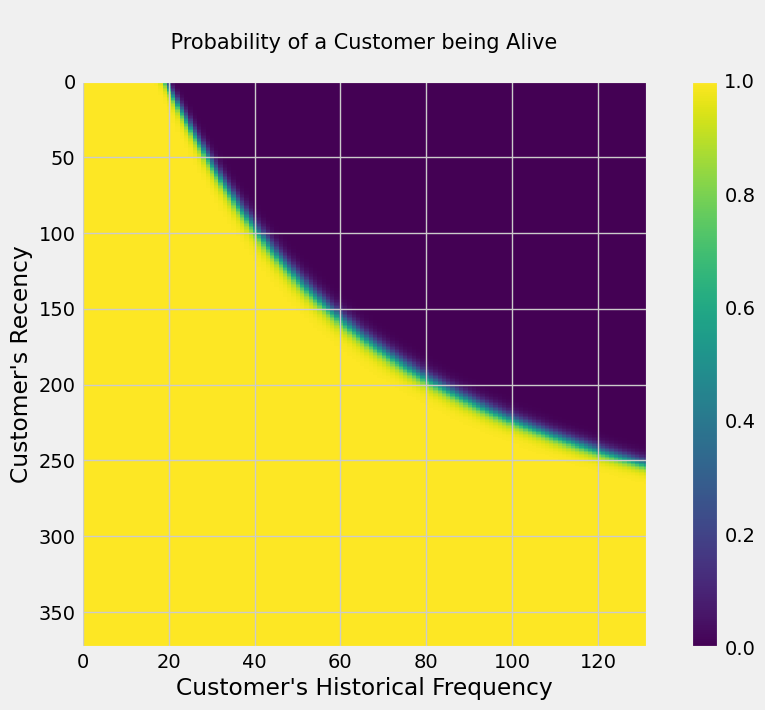

In [14]:
from lifetimes.plotting import plot_probability_alive_matrix

plt.rcParams['figure.figsize']=(10,7)

#lets plot the probability of alive  matrix
plot_probability_alive_matrix(bgf)
plt.title("\n Probability of a Customer being Alive \n", fontsize = 15)
plt.show()

In [15]:
# lets Predict the Purchase of the Customers  for future

# We will  set  the time value as 1 and use a predefinedd function from beta geo fitter
# We are using the conditional expected no. of purchases upto time function for doing this
t = 1
data['predicted_purchases'] = bgf.conditional_expected_number_of_purchases_up_to_time(t,
                                                                                      data['frequency'],
                                                                                      data['recency'],
                                                                                      data['T'])
# lets check the tail of the Dataset
data.sort_values(by='predicted_purchases').tail(5)

,frequency,recency,T,monetary_value,predicted_purchases
CustomerID,,,,,
14606.0,88.0,372.0,373.0,135.890114,0.209731
15311.0,89.0,373.0,373.0,677.729438,0.212099
17841.0,111.0,372.0,373.0,364.452162,0.264180
12748.0,113.0,373.0,373.0,298.360885,0.268915
14911.0,131.0,372.0,373.0,1093.661679,0.311527


# Testing the Model

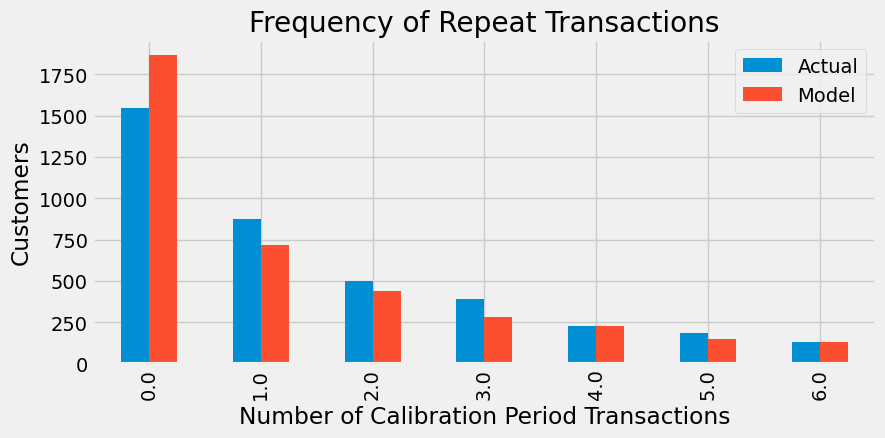

In [16]:
from lifetimes.plotting import plot_period_transactions

#lets plot the periof transactions
plt.rcParams['figure.figsize']=(9,4)
plot_period_transactions(bgf)
plt.show()

In [17]:
from lifetimes.utils import calibration_and_holdout_data

# lets create the calibration and holdout dataset
summary_cal_holdout = calibration_and_holdout_data(df, 'CustomerID','InvoiceDate',
                                                   calibration_period_end='2011-06-08',
                                                   observation_period_end='2011-12-9')
#lets check the head of the calibration and holdout dataset
summary_cal_holdout.head()

,frequency_cal,recency_cal,T_cal,frequency_holdout,duration_holdout
CustomerID,,,,,
12346.0,0.0,0.0,141.0,0.0,184.0
12347.0,2.0,121.0,183.0,4.0,184.0
12348.0,2.0,110.0,174.0,1.0,184.0
12350.0,0.0,0.0,126.0,0.0,184.0
12352.0,3.0,34.0,112.0,3.0,184.0


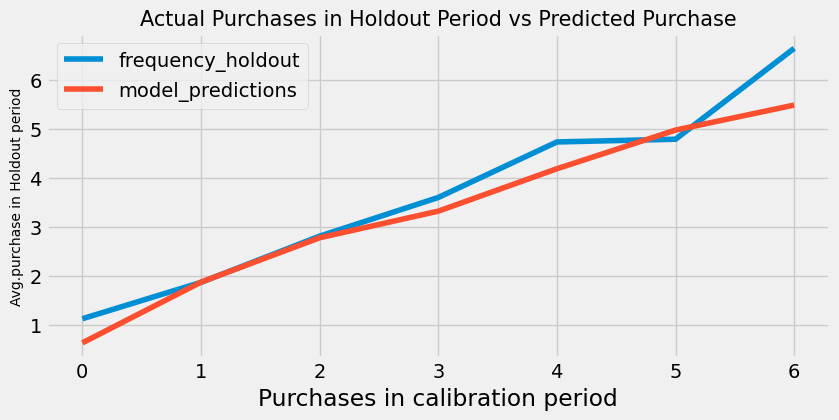

In [18]:
from lifetimes.plotting import plot_calibration_purchases_vs_holdout_purchases

import warnings
warnings.filterwarnings('ignore')

# lets fit the calibration and holdout data
bgf.fit(summary_cal_holdout['frequency_cal'],
        summary_cal_holdout['recency_cal'],
        summary_cal_holdout['T_cal'])

# lets plot the actual purchase in Holdout peiod vs predicted purches
plot_calibration_purchases_vs_holdout_purchases(bgf, summary_cal_holdout)
plt.ylabel('Avg.purchase in Holdout period', fontsize = 10)
plt.title('Actual Purchases in Holdout Period vs Predicted Purchase', fontsize = 15)
plt.show()

In [19]:
# lets do some Real time Predictions
# lets DO a Prediction for the CustomerID NO. 12347
t = 10
individual = data.loc[12347]
print("Purchase Prediction for Customer ID: 12347:", bgf.predict(t, individual['frequency'],
                                                individual['recency'], individual['T']))

# Lets do one more Prediction on Customer ID No.12346
t = 10
individual = data.loc[12346]
print("Purchase Prediction for Customer ID: 12346:", bgf.predict(t, individual['frequency'],
                                                individual['recency'], individual['T']))

Purchase Prediction for Customer ID: 12347: 0.1590669512096759
Purchase Prediction for Customer ID: 12346: 0.013675721453834543


Estimating Custoemr's  Lifetime Value

In [23]:
# LETS Summarize the Data for Returning Customers
returning_customers_summary = data[data['frequency']>0]

print("\nNumber of Returning Customers :", len(returning_customers_summary))
print('------------------------------------')
print(returning_customers_summary.head())


Number of Returning Customers : 2790
------------------------------------
            frequency  recency      T  monetary_value  predicted_purchases
CustomerID                                                                
12347.0           6.0    365.0  367.0      599.701667             0.015834
12348.0           3.0    283.0  358.0      301.480000             0.008820
12352.0           6.0    260.0  296.0      368.256667             0.019089
12356.0           2.0    303.0  325.0      269.905000             0.006927
12358.0           1.0    149.0  150.0      683.200000             0.007991


In [25]:
from lifetimes import GammaGammaFitter

#lets make a model for Gamma Gamma Fitter
ggf = GammaGammaFitter(penalizer_coef = 0)

# lets fit the Data into this Model
ggf.fit(returning_customers_summary['frequency'],
        returning_customers_summary['monetary_value'])

# lets print the Model Coefficients
print(ggf)

<lifetimes.GammaGammaFitter: fitted with 2790 subjects, p: 2.10, q: 3.45, v: 485.57>


In [28]:
# lets Predict the Future Purchases or Cuatomer Lifetime of our customers
x = ggf.conditional_expected_average_profit(
    data['frequency'],
    data['monetary_value'])

# lets print the Head of the Prediction
print("Customer Lifetime Predictions")
x.head()

Customer Lifetime Predictions


CustomerID
12346.0    416.917667
12347.0    569.988807
12348.0    333.762672
12349.0    416.917667
12350.0    416.917667
dtype: float64